In [1]:

# fuisson 1 no ball detection , timestamp


!pip install -q mediapipe==0.10.14 opencv-python-headless librosa scikit-learn scipy matplotlib seaborn tensorflow

import os, cv2, pickle, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import librosa
import mediapipe as mp
import tensorflow as tf
from collections import Counter
from scipy.signal import find_peaks, resample
from scipy.stats import skew, kurtosis
from sklearn.metrics import confusion_matrix, accuracy_score
from google.colab import files
warnings.filterwarnings('ignore')

LABELS       = ['Forehand','Backhand','Serve']
LABEL_COLORS = {'Forehand':'#2E75B6','Backhand':'#FFB800','Serve':'#CC66FF'}
LABEL_MAP    = {0:'Forehand', 1:'Backhand', 2:'Serve'}


SELECTED_JOINTS = [11, 12, 13, 14, 15, 16, 23, 24, 25, 26, 27]
WINDOW_SIZE     = 30
THRESHOLD       = 0.82
STRIDE          = 5
COOLDOWN_FRAMES = 45

print(" Imports ready — mediapipe==0.10.14")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.7/35.7 MB 33.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 6.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 4.25.8 which is incompatible.
opentelemetry-proto 1.38.0 requires protobuf<7.0,>=5.0, but you have protobuf 4.25.8 which is incompatible.
grain 0.2.16 requires protobuf>=5.28.3, but you have protobuf 4.25.8 which is incompatible.
ydf 0.15.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 4.25.8 which is incompatible.
 Imports ready — mediapipe==0.10.14


In [2]:

print("\n1. Upload tennis_cnn_lstm_v1.h5 (camera model)")
u1 = files.upload()
camera_model = tf.keras.models.load_model(list(u1.keys())[0])
print(f" Camera model — input: {camera_model.input_shape}")

print("\n2. Upload accel_cnn_lstm_v4.h5 (accel CNN-LSTM)")
u2 = files.upload()
accel_cnn = tf.keras.models.load_model(list(u2.keys())[0])
print(f" Accel CNN-LSTM — input: {accel_cnn.input_shape}")

print("\n3. Upload accel_svm_v4.pkl (accel SVM)")
u3 = files.upload()
with open(list(u3.keys())[0],'rb') as f:
    svm_data = pickle.load(f)
svm_model  = svm_data['model']
svm_scaler = svm_data['scaler']
print(f" SVM — Court P1: {svm_data['acc_court_p1']:.1f}%")

print("\n4. Upload Au8dio_svm.pkl (audio model)")
u4 = files.upload()
with open(list(u4.keys())[0],'rb') as f:
    audio_data = pickle.load(f)
svm_audio    = audio_data['svm']
scaler_audio = audio_data['scaler']
N_MFCC_AUDIO = audio_data['n_mfcc']
CLIP_AUDIO   = audio_data['clip_duration']
print(f" Audio SVM — n_mfcc={N_MFCC_AUDIO}, clip={CLIP_AUDIO}s")


1. Upload tennis_cnn_lstm_v1.h5 (camera model)


Saving tennis_cnn_lstm_v1.h5 to tennis_cnn_lstm_v1.h5


 Camera model — input: (None, 30, 22)

2. Upload accel_cnn_lstm_v4.h5 (accel CNN-LSTM)


Saving accel_cnn_lstm_v4.h5 to accel_cnn_lstm_v4.h5
 Accel CNN-LSTM — input: (None, 60, 4)

3. Upload accel_svm_v4.pkl (accel SVM)


Saving accel_svm_v4.pkl to accel_svm_v4.pkl
 SVM — Court P1: 61.5%

4. Upload Au8dio_svm.pkl (audio model)


Saving Au8dio_svm.pkl to Au8dio_svm.pkl
 Audio SVM — n_mfcc=40, clip=0.5s


In [3]:

print("\n5. Upload session2.mp4 (Video 2 — Player 1)")
uv2 = files.upload(); V2_VIDEO = list(uv2.keys())[0]
print(f" {V2_VIDEO}")

print("\n6. Upload results_2.csv (Video 2 accel)")
ua2 = files.upload(); V2_ACCEL = list(ua2.keys())[0]
print(f" {V2_ACCEL}")

print("\n7. Upload session3.mp4 (Video 3 — Player 2)")
uv3 = files.upload(); V3_VIDEO = list(uv3.keys())[0]
print(f" {V3_VIDEO}")

print("\n8. Upload results_3.csv (Video 3 accel)")
ua3 = files.upload(); V3_ACCEL = list(ua3.keys())[0]
print(f"{V3_ACCEL}")

print("\n All uploaded")


5. Upload session2.mp4 (Video 2 — Player 1)


Saving ss2.mp4 to ss2.mp4
 ss2.mp4

6. Upload results_2.csv (Video 2 accel)


Saving results 2.csv to results 2.csv
 results 2.csv

7. Upload session3.mp4 (Video 3 — Player 2)


Saving ss3.mp4 to ss3.mp4
 ss3.mp4

8. Upload results_3.csv (Video 3 accel)


Saving results 3.csv to results 3.csv
results 3.csv

 All uploaded


In [4]:

GT_MAP = {'F':0,'B':1,'S':2}

V2_GT_STR      = ['S','F','S','F','F','B','S','S','B','F','F','B','F']
V2_GT          = [GT_MAP[x] for x in V2_GT_STR]
V2_ACCEL_TIMES = [16.67,19.25,25.77,29.06,31.81,
                  35.82,54.31,57.32,60.98,64.54,
                  67.47,71.10,72.20]

V3_GT_STR      = ['S','F','B','F','F']
V3_GT          = [GT_MAP[x] for x in V3_GT_STR]
V3_ACCEL_TIMES = [11.89,15.04,19.11,23.47,27.50]

WHOOP = {'Avg HR':147,'Max HR':178,'Strain':4.6,'Calories':23,
         'Zone1':39,'Zone2':8,'Zone3':4,'Zone4':49,'Zone5':0}

print(f"V2: {len(V2_GT)} strokes — {' '.join(V2_GT_STR)}")
print(f"V3: {len(V3_GT)} strokes — {' '.join(V3_GT_STR)}")

V2: 13 strokes — S F S F F B S S B F F B F
V3: 5 strokes — S F B F F


In [9]:

from mediapipe.python.solutions import pose as mp_pose_lib

SELECTED_JOINTS = [11, 12, 13, 14, 15, 16, 23, 24, 25, 26, 27]
WINDOW_SIZE     = 30
THRESHOLD       = 0.82

def extract_skeleton(video_path):
    pose = mp_pose_lib.Pose(
        static_image_mode=False,
        model_complexity=1,
        min_detection_confidence=0.5,
        min_tracking_confidence=0.6
    )
    cap           = cv2.VideoCapture(video_path)
    fps           = cap.get(cv2.CAP_PROP_FPS) or 30.0
    width         = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height        = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    all_skeletons = []

    print(f"  {fps:.0f}fps  {width}×{height}")
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret: break
        rgb     = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        results = pose.process(rgb)
        if results.pose_landmarks:
            lm  = results.pose_landmarks.landmark
            pts = [[lm[i].x, lm[i].y] for i in SELECTED_JOINTS]
        else:

            pts = all_skeletons[-1] if all_skeletons else [[0.0, 0.0]] * len(SELECTED_JOINTS)
        all_skeletons.append(pts)

    cap.release()
    pose.close()
    skeleton = np.array(all_skeletons)
    print(f"   Skeleton: {skeleton.shape}")
    return skeleton, fps, width, height

print(" Extracting skeleton from Video 2...........")
skel_v2, fps_v2, w_v2, h_v2 = extract_skeleton(V2_VIDEO)

print("\n Extracting skeleton from Video 3....")
skel_v3, fps_v3, w_v3, h_v3 = extract_skeleton(V3_VIDEO)

 Extracting skeleton from Video 2...........
  59fps  2340×1080
   Skeleton: (2260, 11, 2)

 Extracting skeleton from Video 3....
  60fps  2340×1080
   Skeleton: (1145, 11, 2)


In [10]:

def classify_camera_at_times(skeleton, fps, stroke_times, gt_list, video_name):

    results = []
    print(f"\n  {video_name}  camera classification:")
    for i, (t, gt) in enumerate(zip(stroke_times, gt_list)):
        centre_frame = int(t * fps)
        half         = WINDOW_SIZE // 2
        f0           = max(0, centre_frame - half)
        f1           = min(len(skeleton), f0 + WINDOW_SIZE)
        f0           = max(0, f1 - WINDOW_SIZE)

        window = skeleton[f0:f1]

        if len(window) < WINDOW_SIZE:

            pad    = np.tile(window[-1], (WINDOW_SIZE-len(window),1,1))
            window = np.vstack([window, pad])


        seq    = window.reshape(WINDOW_SIZE, 11, 2)
        seq_f  = window.reshape(WINDOW_SIZE, 22)

        hip_x  = seq_f[:, 12]
        hip_y  = seq_f[:, 13]

        seq_3d  = seq.copy()
        hip_3d  = np.stack([hip_x, hip_y], axis=1)[:, None, :]
        seq_3d  = seq_3d - hip_3d
        seq_inp = seq_3d.reshape(1, WINDOW_SIZE, 22)

        probs  = camera_model.predict(seq_inp, verbose=0)[0]
        pred   = int(np.argmax(probs))
        conf   = float(probs[pred])
        match  = '✅' if pred==gt else '❌'
        print(f"    t={t:.2f}s  GT:{LABELS[gt]:<10} Pred:{LABELS[pred]:<10} "
              f"conf={conf*100:.0f}%  {match}")
        results.append({'t':t,'pred':pred,'conf':conf,'probs':probs.tolist()})

    acc = sum(r['pred']==gt for r,gt in zip(results,gt_list)) / len(gt_list) * 100
    print(f"  Camera accuracy: {acc:.1f}%")
    return results

cam_v2 = classify_camera_at_times(skel_v2, fps_v2, V2_ACCEL_TIMES, V2_GT, "Video 2")
cam_v3 = classify_camera_at_times(skel_v3, fps_v3, V3_ACCEL_TIMES, V3_GT, "Video 3")



  Video 2 — camera classification:
    t=16.67s  GT:Serve      Pred:Backhand   conf=100%  ❌
    t=19.25s  GT:Forehand   Pred:Forehand   conf=100%  ✅
    t=25.77s  GT:Serve      Pred:Forehand   conf=100%  ❌
    t=29.06s  GT:Forehand   Pred:Forehand   conf=100%  ✅
    t=31.81s  GT:Forehand   Pred:Forehand   conf=100%  ✅
    t=35.82s  GT:Backhand   Pred:Forehand   conf=100%  ❌
    t=54.31s  GT:Serve      Pred:Forehand   conf=100%  ❌
    t=57.32s  GT:Serve      Pred:Forehand   conf=100%  ❌
    t=60.98s  GT:Backhand   Pred:Forehand   conf=100%  ❌
    t=64.54s  GT:Forehand   Pred:Forehand   conf=100%  ✅
    t=67.47s  GT:Forehand   Pred:Forehand   conf=100%  ✅
    t=71.10s  GT:Backhand   Pred:Forehand   conf=100%  ❌
    t=72.20s  GT:Forehand   Pred:Forehand   conf=100%  ✅
  Camera accuracy: 46.2%

  Video 3 — camera classification:
    t=11.89s  GT:Serve      Pred:Forehand   conf=100%  ❌
    t=15.04s  GT:Forehand   Pred:Forehand   conf=100%  ✅
    t=19.11s  GT:Backhand   Pred:Forehand   conf

In [12]:

def extract_audio_features(clip, sr):
    if len(clip) < sr * 0.1: return None
    try:
        mfcc   = librosa.feature.mfcc(y=clip, sr=sr, n_mfcc=N_MFCC_AUDIO)
        chroma = librosa.feature.chroma_stft(y=clip, sr=sr)
        zcr    = librosa.feature.zero_crossing_rate(clip)
        rmse   = librosa.feature.rms(y=clip)
        return np.concatenate([mfcc.mean(axis=1), mfcc.std(axis=1),
                               chroma.mean(axis=1),
                               zcr.mean(axis=1), rmse.mean(axis=1)])
    except: return None

def detect_audio_svm(video_path, fps):

    audio_tmp = '/tmp/aud_extract.wav'
    os.system(f'ffmpeg -y -i "{video_path}" -q:a 0 -map a "{audio_tmp}" -loglevel quiet')
    if not os.path.exists(audio_tmp):
        print("    Audio extraction       failed"); return [], 0

    y, sr        = librosa.load(audio_tmp, sr=None)
    duration     = len(y) / sr
    detections   = []
    last_detect  = -1.0
    MIN_GAP      = 1.0
    PROB_THRESH  = 0.75
    STEP         = 0.1

    t = CLIP_AUDIO / 2
    while t < duration - CLIP_AUDIO/2:
        start = max(0, t - 0.1)
        end   = min(duration, t + CLIP_AUDIO)
        clip  = y[int(start*sr):int(end*sr)]
        feat  = extract_audio_features(clip, sr)
        if feat is not None:
            prob = svm_audio.predict_proba(scaler_audio.transform([feat]))[0][1]
            if prob >= PROB_THRESH and (t - last_detect) >= MIN_GAP:
                frame_num = int(t * fps)
                detections.append((t, frame_num, prob))
                last_detect = t
        t += STEP

    print(f"   Audio SVM: {len(detections)} contacts")
    print(f"     Times: {[round(d[0],2) for d in detections]}")
    return detections, duration

def audio_near(detections, t_stroke, fps, window_frames=45):
    for t_sec, f_num, conf in detections:
        if abs(t_sec - t_stroke) <= window_frames/fps:
            return True, conf
    return False, 0.0

print("\n Audio Detection — Video 2.")
aud_v2, dur_v2 = detect_audio_svm(V2_VIDEO, fps_v2)

print("\n Audio Detection — Video 3")
aud_v3, dur_v3 = detect_audio_svm(V3_VIDEO, fps_v3)



 Audio Detection — Video 2.
   Audio SVM: 14 contacts
     Times: [1.35, 2.95, 4.25, 6.95, 10.05, 11.75, 16.45, 21.75, 26.75, 30.65, 32.35, 33.55, 35.35, 36.75]

 Audio Detection — Video 3
   Audio SVM: 1 contacts
     Times: [1.45]


In [13]:

CLIP_SEC = 0.6
N_ACCEL  = 60

def load_accel(path):
    df = pd.read_csv(path, comment='#')
    df.columns = ['time','ax','ay','az','aT']
    return df

def get_accel_clip(df, t_center):
    t0,t1 = t_center-CLIP_SEC/2, t_center+CLIP_SEC/2
    c = df[(df.time>=t0)&(df.time<t1)]
    return c if len(c)>=20 else None

def handcrafted_features(clip):
    feats = []
    for col in ['ax','ay','az','aT']:
        sig = clip[col].values
        pv  = np.max(np.abs(sig))+1e-8
        sn  = sig/pv
        feats += [np.mean(sn),np.std(sn),np.max(sn),np.min(sn),
                  np.max(sn)-np.min(sn),float(skew(sn)),float(kurtosis(sn)),
                  pv, np.sqrt(np.mean(sig**2))]
    aT = clip['aT'].values
    ax = clip['ax'].values
    feats.append(np.max(aT))
    feats.append(float(np.sum(np.diff(np.sign(ax))!=0))/len(ax))
    feats.append(np.sum(aT**2)/len(aT))
    total = sum(np.mean(np.abs(clip[c].values)) for c in ['ax','ay','az'])+1e-8
    for col in ['ax','ay','az']:
        feats.append(np.mean(np.abs(clip[col].values))/total)
    return np.array(feats, dtype=np.float32)

def raw_window_accel(df, t_center):
    clip = get_accel_clip(df, t_center)
    if clip is None: return None
    raw  = clip[['ax','ay','az','aT']].values
    norm = raw / (np.max(np.abs(raw),axis=0)+1e-8)
    return resample(norm, N_ACCEL, axis=0).astype(np.float32)

def classify_accel(df, times, gt_list, name):
    results = []
    print(f"\n  {name} — accel classification:")
    for i,(t,gt) in enumerate(zip(times,gt_list)):
        clip = get_accel_clip(df, t)
        rw   = raw_window_accel(df, t)
        if clip is None or rw is None:
            print(f"    t={t:.2f}s    clip too short")
            results.append({'t':t,'svm':-1,'cnn':-1,'svm_conf':0,'cnn_conf':0})
            continue
        feat     = handcrafted_features(clip)
        X_sc     = svm_scaler.transform([feat])
        svm_pred = int(svm_model.predict(X_sc)[0])
        svm_prob = svm_model.predict_proba(X_sc)[0]
        cnn_prob = accel_cnn.predict(rw[np.newaxis], verbose=0)[0]
        cnn_pred = int(np.argmax(cnn_prob))
        ms = '✅' if cnn_pred==gt else '❌'
        print(f"    t={t:.2f}s  GT:{LABELS[gt]:<10} "
              f"SVM:{LABELS[svm_pred]:<10} CNN:{LABELS[cnn_pred]:<10} {ms}")
        results.append({
            't':t,'svm':svm_pred,'cnn':cnn_pred,
            'svm_conf':float(svm_prob[svm_pred])*100,
            'cnn_conf':float(cnn_prob[cnn_pred])*100,
        })
    svm_acc = sum(r['svm']==gt for r,gt in zip(results,gt_list))/len(gt_list)*100
    cnn_acc = sum(r['cnn']==gt for r,gt in zip(results,gt_list))/len(gt_list)*100
    print(f"  SVM: {svm_acc:.1f}%  CNN-LSTM: {cnn_acc:.1f}%")
    return results

print("\n Accel Classification..")
df_v2  = load_accel(V2_ACCEL)
df_v3  = load_accel(V3_ACCEL)
acc_v2 = classify_accel(df_v2, V2_ACCEL_TIMES, V2_GT, "Video 2")
acc_v3 = classify_accel(df_v3, V3_ACCEL_TIMES, V3_GT, "Video 3")


 Accel Classification..

  Video 2 — accel classification:
    t=16.67s  GT:Serve      SVM:Serve      CNN:Serve      ✅
    t=19.25s  GT:Forehand   SVM:Forehand   CNN:Forehand   ✅
    t=25.77s  GT:Serve      SVM:Serve      CNN:Serve      ✅
    t=29.06s  GT:Forehand   SVM:Forehand   CNN:Forehand   ✅
    t=31.81s  GT:Forehand   SVM:Forehand   CNN:Forehand   ✅
    t=35.82s  GT:Backhand   SVM:Forehand   CNN:Backhand   ✅
    t=54.31s  GT:Serve      SVM:Serve      CNN:Serve      ✅
    t=57.32s  GT:Serve      SVM:Backhand   CNN:Backhand   ❌
    t=60.98s  GT:Backhand   SVM:Forehand   CNN:Forehand   ❌
    t=64.54s  GT:Forehand   SVM:Forehand   CNN:Forehand   ✅
    t=67.47s  GT:Forehand   SVM:Backhand   CNN:Backhand   ❌
    t=71.10s  GT:Backhand   SVM:Forehand   CNN:Forehand   ❌
    t=72.20s  GT:Forehand   SVM:Forehand   CNN:Serve      ❌
  SVM: 61.5%  CNN-LSTM: 61.5%

  Video 3 — accel classification:
    t=11.89s  GT:Serve      SVM:Serve      CNN:Serve      ✅
    t=15.04s  GT:Forehand   SVM:Ser

In [14]:

def fuse(cam_pred, cam_conf, svm_pred, svm_conf, cnn_pred, cnn_conf):
    votes = np.zeros(3)
    if cam_pred >= 0: votes[cam_pred] += 2.0 * cam_conf
    if cnn_pred >= 0: votes[cnn_pred] += 2.0 * (cnn_conf/100)
    if svm_pred >= 0: votes[svm_pred] += 1.0 * (svm_conf/100)
    total = np.sum(votes)
    if total == 0: return cnn_pred if cnn_pred>=0 else 0, 0.0
    votes /= total
    fp = int(np.argmax(votes))
    return fp, float(votes[fp])

print("\n Running Fusion..")
v2_fusion, v3_fusion = [], []

for i,t in enumerate(V2_ACCEL_TIMES):
    aud_ok, aud_conf = audio_near(aud_v2, t, fps_v2)
    fp, fc = fuse(cam_v2[i]['pred'], cam_v2[i]['conf'],
                  acc_v2[i]['svm'],  acc_v2[i]['svm_conf'],
                  acc_v2[i]['cnn'],  acc_v2[i]['cnn_conf'])
    v2_fusion.append({
        't':t,'gt':V2_GT[i],
        'cam':cam_v2[i]['pred'],'cam_conf':cam_v2[i]['conf'],
        'svm':acc_v2[i]['svm'],'svm_conf':acc_v2[i]['svm_conf'],
        'cnn':acc_v2[i]['cnn'],'cnn_conf':acc_v2[i]['cnn_conf'],
        'fusion':fp,'fusion_conf':fc,
        'audio':aud_ok,'audio_conf':aud_conf,
        'agree': cam_v2[i]['pred']==acc_v2[i]['cnn'],
    })

for i,t in enumerate(V3_ACCEL_TIMES):
    aud_ok, aud_conf = audio_near(aud_v3, t, fps_v3)
    fp, fc = fuse(cam_v3[i]['pred'], cam_v3[i]['conf'],
                  acc_v3[i]['svm'],  acc_v3[i]['svm_conf'],
                  acc_v3[i]['cnn'],  acc_v3[i]['cnn_conf'])
    v3_fusion.append({
        't':t,'gt':V3_GT[i],
        'cam':cam_v3[i]['pred'],'cam_conf':cam_v3[i]['conf'],
        'svm':acc_v3[i]['svm'],'svm_conf':acc_v3[i]['svm_conf'],
        'cnn':acc_v3[i]['cnn'],'cnn_conf':acc_v3[i]['cnn_conf'],
        'fusion':fp,'fusion_conf':fc,
        'audio':aud_ok,'audio_conf':aud_conf,
        'agree': cam_v3[i]['pred']==acc_v3[i]['cnn'],
    })



 Running Fusion..


In [15]:

def results_table(fl, title):
    n = len(fl)
    print("\n"+"═"*90)
    print(title)
    print("═"*90)
    print(f"{'#':<3}{'t':>7}  {'GT':>10}  {'Camera':>10}  {'SVM':>10}  "
          f"{'CNN':>10}  {'FUSION':>10}  {'🎵':>3}  {'✓/✗'}")
    print("─"*90)
    cc=cs=cn=cf=0
    for i,r in enumerate(fl):
        gt = r['gt']
        lbl= lambda p: LABELS[p][:8] if p>=0 else 'FAIL'
        mk = lambda p: '✅' if p==gt else '❌'
        aud= '🎵' if r['audio'] else '  '
        print(f"{i+1:<3}{r['t']:>6.2f}s  {LABELS[gt]:>10}  "
              f"{lbl(r['cam']):>10}{mk(r['cam'])}  "
              f"{lbl(r['svm']):>10}{mk(r['svm'])}  "
              f"{lbl(r['cnn']):>10}{mk(r['cnn'])}  "
              f"{lbl(r['fusion']):>10}{mk(r['fusion'])}  {aud}")
        if r['cam']==gt:    cc+=1
        if r['svm']==gt:    cs+=1
        if r['cnn']==gt:    cn+=1
        if r['fusion']==gt: cf+=1
    print("─"*90)
    print(f"  Camera:   {cc}/{n} = {cc/n*100:.1f}%")
    print(f"  SVM:      {cs}/{n} = {cs/n*100:.1f}%")
    print(f"  CNN-LSTM: {cn}/{n} = {cn/n*100:.1f}%")
    print(f"  FUSION:   {cf}/{n} = {cf/n*100:.1f}%  ← FINAL SYSTEM")
    agree = sum(1 for r in fl if r['agree'])
    print(f"  Camera–CNN agreement: {agree}/{n} = {agree/n*100:.0f}%")
    audio_hits = sum(1 for r in fl if r['audio'])
    print(f"  Audio confirmed: {audio_hits}/{n} strokes")
    return cc/n, cs/n, cn/n, cf/n

a2 = results_table(v2_fusion,
    "VIDEO 2 — Player 1 | Camera+SVM+CNN+Audio+Whoop | 13 strokes")
a3 = results_table(v3_fusion,
    "VIDEO 3 — Player 2 (Cross-Player) | Camera+SVM+CNN+Audio | 5 strokes")

cam_v2a,svm_v2a,cnn_v2a,fus_v2a = a2
cam_v3a,svm_v3a,cnn_v3a,fus_v3a = a3


══════════════════════════════════════════════════════════════════════════════════════════
VIDEO 2 — Player 1 | Camera+SVM+CNN+Audio+Whoop | 13 strokes
══════════════════════════════════════════════════════════════════════════════════════════
#        t          GT      Camera         SVM         CNN      FUSION    🎵  ✓/✗
──────────────────────────────────────────────────────────────────────────────────────────
1   16.67s       Serve    Backhand❌       Serve✅       Serve✅       Serve✅  🎵
2   19.25s    Forehand    Forehand✅    Forehand✅    Forehand✅    Forehand✅    
3   25.77s       Serve    Forehand❌       Serve✅       Serve✅       Serve✅    
4   29.06s    Forehand    Forehand✅    Forehand✅    Forehand✅    Forehand✅    
5   31.81s    Forehand    Forehand✅    Forehand✅    Forehand✅    Forehand✅  🎵
6   35.82s    Backhand    Forehand❌    Forehand❌    Backhand✅    Forehand❌  🎵
7   54.31s       Serve    Forehand❌       Serve✅       Serve✅       Serve✅    
8   57.32s       Serve    Forehand

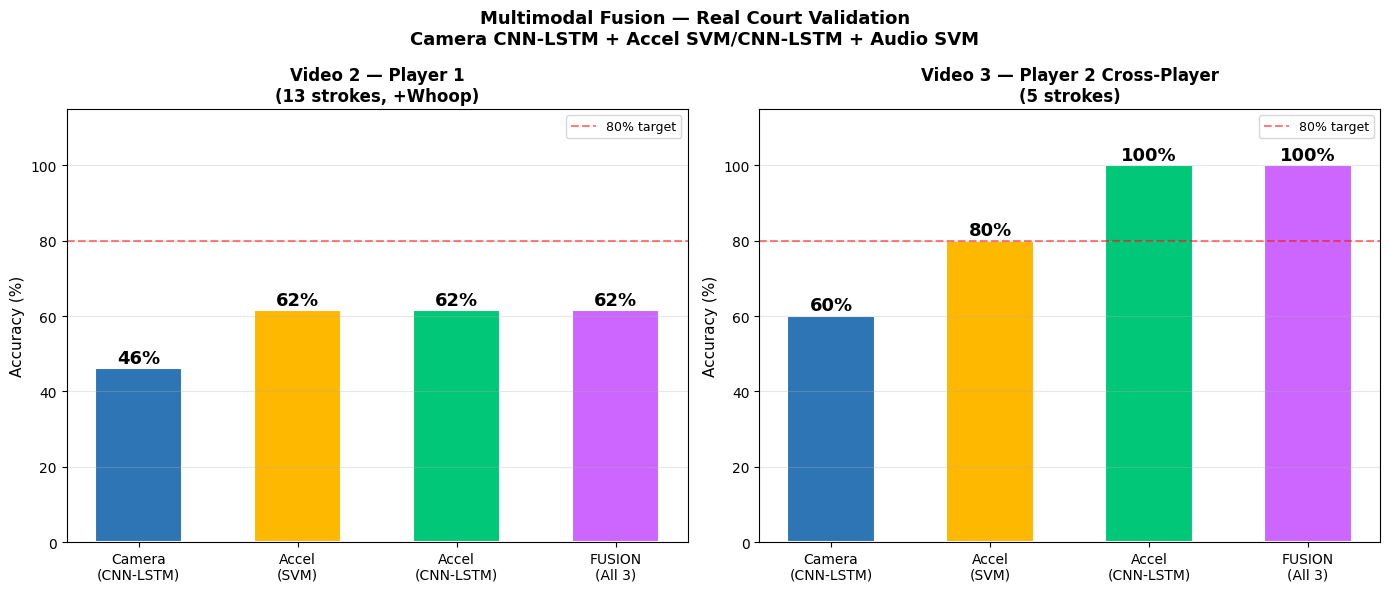

 fusion_accuracy.png


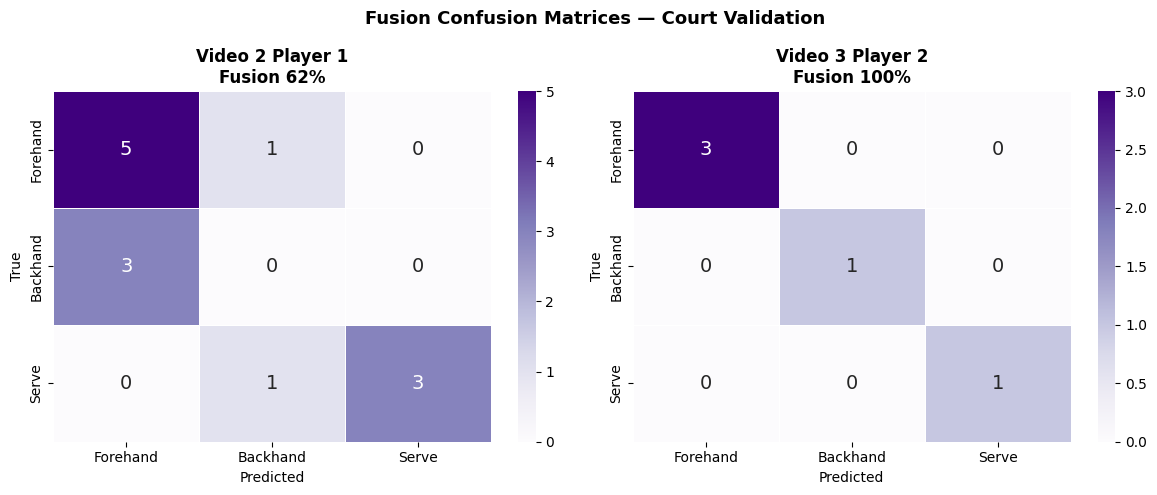

 fusion_confusion.png


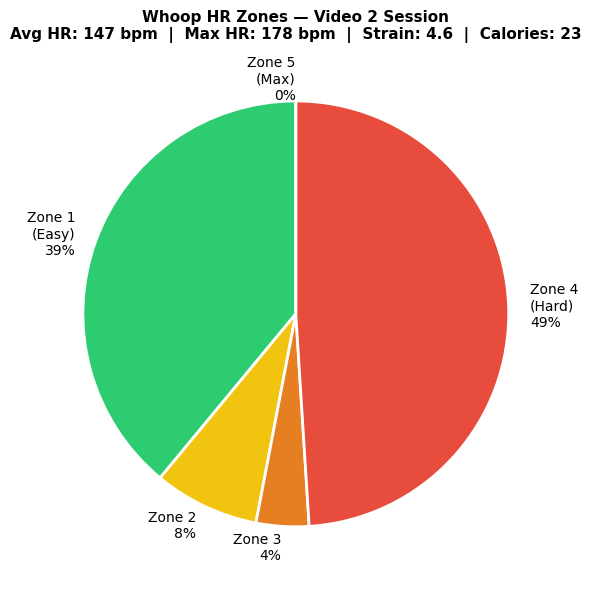

 whoop_zones.png


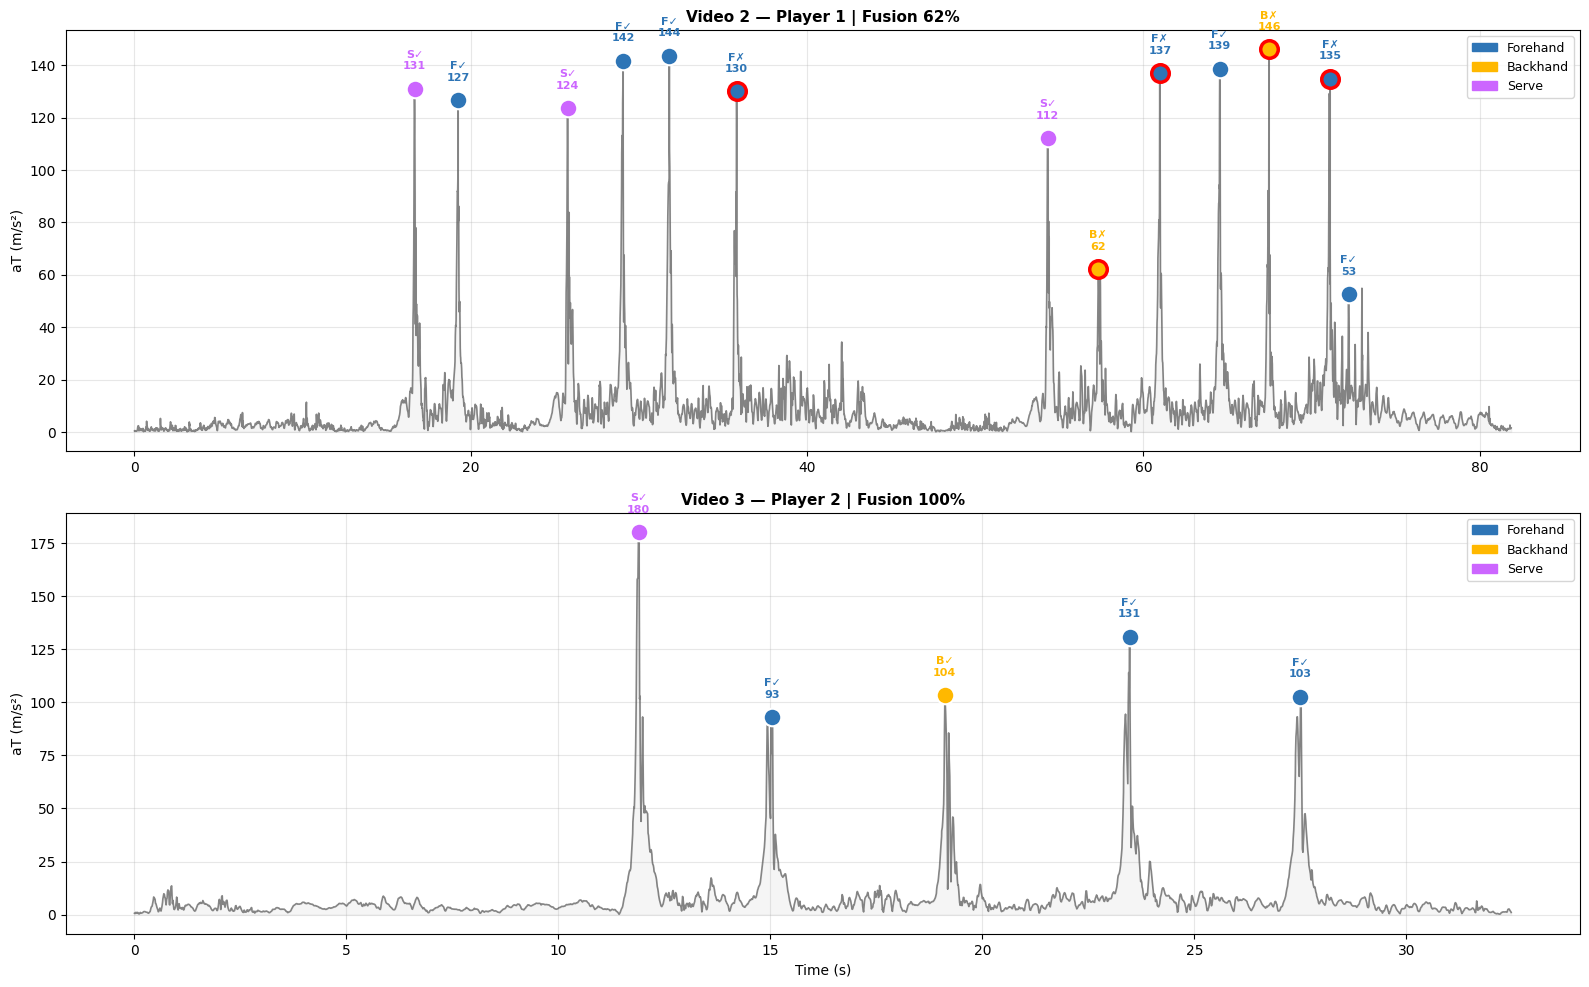

 fusion_signal.png

═════════════════════════════════════════════════════════════════
 COPY INTO REPORT
═════════════════════════════════════════════════════════════════

VIDEO 2 — Player 1 (Camera+Accel+Audio+Whoop) — 13 strokes
  Camera CNN-LSTM  : 46.2%  (6/13)
  Accel SVM        : 61.5%  (8/13)
  Accel CNN-LSTM   : 61.5%  (8/13)
  FUSION (all 3)   : 61.5%  (8/13)
  Audio contacts   : 14 detected
  Whoop Avg HR     : 147 bpm
  Whoop Max HR     : 178 bpm
  Whoop Strain     : 4.6
  Zone 4 (hard)    : 49% of session

VIDEO 3 — Player 2 Cross-Player (Camera+Accel+Audio) — 5 strokes
  Camera CNN-LSTM  : 60.0%  (3/5)
  Accel SVM        : 80.0%  (4/5)
  Accel CNN-LSTM   : 100.0%  (5/5)
  FUSION (all 3)   : 100.0%  (5/5)
  Audio contacts   : 1 detected
═════════════════════════════════════════════════════════════════


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

⬇  fusion_accuracy.png


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

⬇  whoop_zones.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

⬇  fusion_signal.png

 DONE  V2:62%  V3:100%


In [17]:

fig, axes = plt.subplots(1,2,figsize=(14,6))
mods   = ['Camera\n(CNN-LSTM)','Accel\n(SVM)','Accel\n(CNN-LSTM)','FUSION\n(All 3)']
cols   = ['#2E75B6','#FFB800','#00C878','#CC66FF']
for ax,(accs,title,n) in zip(axes,[
    ([cam_v2a,svm_v2a,cnn_v2a,fus_v2a],
     f'Video 2 — Player 1\n(13 strokes, +Whoop)',13),
    ([cam_v3a,svm_v3a,cnn_v3a,fus_v3a],
     f'Video 3 — Player 2 Cross-Player\n(5 strokes)',5),
]):
    bars = ax.bar(mods,[a*100 for a in accs],color=cols,
                  width=0.55,edgecolor='white',linewidth=1.5)
    for bar,a in zip(bars,accs):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1.5,
                f'{a*100:.0f}%', ha='center', fontsize=13, fontweight='bold')
    ax.set_ylim(0,115)
    ax.set_ylabel('Accuracy (%)',fontsize=11)
    ax.set_title(title,fontsize=12,fontweight='bold')
    ax.axhline(80,color='red',ls='--',lw=1.5,alpha=0.5,label='80% target')
    ax.legend(fontsize=9)
    ax.grid(True,alpha=0.3,axis='y')
plt.suptitle('Multimodal Fusion — Real Court Validation\nCamera CNN-LSTM + Accel SVM/CNN-LSTM + Audio SVM',
             fontsize=13,fontweight='bold')
plt.tight_layout()
plt.savefig('fusion_accuracy.png',dpi=150,bbox_inches='tight')
plt.show(); print(" fusion_accuracy.png")


fig, axes = plt.subplots(1,2,figsize=(12,5))
for ax,fl,title in [
    (axes[0],v2_fusion,f'Video 2 Player 1\nFusion {fus_v2a*100:.0f}%'),
    (axes[1],v3_fusion,f'Video 3 Player 2\nFusion {fus_v3a*100:.0f}%'),
]:
    cm = confusion_matrix([r['gt'] for r in fl],
                          [r['fusion'] for r in fl],labels=[0,1,2])
    sns.heatmap(cm,annot=True,fmt='d',cmap='Purples',
                xticklabels=LABELS,yticklabels=LABELS,
                linewidths=0.5,ax=ax,annot_kws={"size":14})
    ax.set_title(title,fontsize=12,fontweight='bold')
    ax.set_ylabel('True'); ax.set_xlabel('Predicted')
plt.suptitle('Fusion Confusion Matrices — Court Validation',fontsize=13,fontweight='bold')
plt.tight_layout()
plt.savefig('fusion_confusion.png',dpi=150,bbox_inches='tight')
plt.show(); print(" fusion_confusion.png")


fig,ax = plt.subplots(figsize=(7,6))
zones = [WHOOP['Zone1'],WHOOP['Zone2'],WHOOP['Zone3'],WHOOP['Zone4'],WHOOP['Zone5']]
zlbls = ['Zone 1\n(Easy)','Zone 2','Zone 3','Zone 4\n(Hard)','Zone 5\n(Max)']
zcols = ['#2ECC71','#F1C40F','#E67E22','#E74C3C','#8E44AD']
ax.pie(zones,labels=[f'{l}\n{v}%' for l,v in zip(zlbls,zones)],
       colors=zcols,startangle=90,wedgeprops={'edgecolor':'white','lw':2})
ax.set_title(f"Whoop HR Zones — Video 2 Session\n"
             f"Avg HR: {WHOOP['Avg HR']} bpm  |  Max HR: {WHOOP['Max HR']} bpm  |  "
             f"Strain: {WHOOP['Strain']}  |  Calories: {WHOOP['Calories']}",
             fontsize=11,fontweight='bold')
plt.tight_layout()
plt.savefig('whoop_zones.png',dpi=150)
plt.show(); print(" whoop_zones.png")


fig,axes = plt.subplots(2,1,figsize=(16,10))
for ax,df_acc,fl,title in [
    (axes[0],df_v2,v2_fusion,f'Video 2 — Player 1 | Fusion {fus_v2a*100:.0f}%'),
    (axes[1],df_v3,v3_fusion,f'Video 3 — Player 2 | Fusion {fus_v3a*100:.0f}%'),
]:
    ax.plot(df_acc['time'],df_acc['aT'],color='#555',lw=1.2,alpha=0.7)
    ax.fill_between(df_acc['time'],0,df_acc['aT'],alpha=0.06,color='#555')
    for r in fl:
        idx  = (df_acc['time']-r['t']).abs().idxmin()
        aT_v = df_acc['aT'].iloc[idx]
        col  = LABEL_COLORS.get(LABELS[r['fusion']],'#888') if r['fusion']>=0 else '#888'
        match= r['fusion']==r['gt']
        ax.scatter(r['t'],aT_v,s=160,color=col,
                   edgecolors='white' if match else 'red',
                   linewidths=1.5 if match else 2.5,zorder=5)
        lbl = f"{LABELS[r['fusion']][:1]}{'✓' if match else '✗'}\n{aT_v:.0f}"
        ax.annotate(lbl,(r['t'],aT_v),xytext=(0,14),
                    textcoords='offset points',ha='center',
                    fontsize=8,fontweight='bold',color=col)
    patches=[mpatches.Patch(color=c,label=l) for l,c in LABEL_COLORS.items()]
    ax.legend(handles=patches,fontsize=9,loc='upper right')
    ax.set_title(title,fontsize=11,fontweight='bold')
    ax.set_ylabel('aT (m/s²)'); ax.grid(True,alpha=0.3)
axes[-1].set_xlabel('Time (s)')
plt.tight_layout()
plt.savefig('fusion_signal.png',dpi=150,bbox_inches='tight')
plt.show(); print(" fusion_signal.png")


print("\n"+"═"*65)
print(" COPY INTO REPORT")
print("═"*65)
print(f"\nVIDEO 2 — Player 1 (Camera+Accel+Audio+Whoop) — 13 strokes")
print(f"  Camera CNN-LSTM  : {cam_v2a*100:.1f}%  ({int(cam_v2a*13)}/13)")
print(f"  Accel SVM        : {svm_v2a*100:.1f}%  ({int(svm_v2a*13)}/13)")
print(f"  Accel CNN-LSTM   : {cnn_v2a*100:.1f}%  ({int(cnn_v2a*13)}/13)")
print(f"  FUSION (all 3)   : {fus_v2a*100:.1f}%  ({int(round(fus_v2a*13))}/13)")
print(f"  Audio contacts   : {len(aud_v2)} detected")
print(f"  Whoop Avg HR     : {WHOOP['Avg HR']} bpm")
print(f"  Whoop Max HR     : {WHOOP['Max HR']} bpm")
print(f"  Whoop Strain     : {WHOOP['Strain']}")
print(f"  Zone 4 (hard)    : {WHOOP['Zone4']}% of session")
print(f"\nVIDEO 3 — Player 2 Cross-Player (Camera+Accel+Audio) — 5 strokes")
print(f"  Camera CNN-LSTM  : {cam_v3a*100:.1f}%  ({int(cam_v3a*5)}/5)")
print(f"  Accel SVM        : {svm_v3a*100:.1f}%  ({int(svm_v3a*5)}/5)")
print(f"  Accel CNN-LSTM   : {cnn_v3a*100:.1f}%  ({int(cnn_v3a*5)}/5)")
print(f"  FUSION (all 3)   : {fus_v3a*100:.1f}%  ({int(round(fus_v3a*5))}/5)")
print(f"  Audio contacts   : {len(aud_v3)} detected")
print("═"*65)

for fname in ['fusion_accuracy.png','fusion_confusion.png',
              'whoop_zones.png','fusion_signal.png']:
    if os.path.exists(fname):
        files.download(fname)
        print(f"⬇  {fname}")

print(f"\n DONE  V2:{fus_v2a*100:.0f}%  V3:{fus_v3a*100:.0f}%")